In [3]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU is NOT available")

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [4]:
!pip install -q kagglehub transformers datasets evaluate accelerate \
    scikit-learn pandas numpy matplotlib seaborn pillow \
    opencv-python grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 3.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.8 MB/s eta 0:00:00


In [5]:
import torch
import torchvision
import pandas as pd
import numpy as np
from PIL import Image

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
Torchvision: 0.26.0+cu128
GPU available: True
GPU name: Tesla T4


In [6]:
from google.colab import files

uploaded = files.upload()

Saving kaggle.json to kaggle.json


In [7]:
import os

os.makedirs("/root/.kaggle", exist_ok=True)

!cp kaggle.json /root/.kaggle/kaggle.json
!chmod 600 /root/.kaggle/kaggle.json

print("Kaggle API configured successfully!")

Kaggle API configured successfully!


In [8]:
!kaggle datasets list -s "chest xray14"

No datasets found


In [9]:
!pip install -q --upgrade kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 6.5 MB/s eta 0:00:00


In [10]:
import kaggle
print(kaggle.__version__)

2.2.4


In [11]:
!kaggle datasets list --max-size 10 -s "chest"

ref                                                            title                                                  size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-------------------------------------------------------------  ----------------------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
akorenvais/covid19-image-data-collection                       COVID-19 image data collection                    550525030  2026-08-24 19:40:56.253000           1173          5  0.7058824        
arisafriyanto/chest-x-ray-for-pulmonology-splitted-data        Chest X-Ray for Pulmonology (Splitted Data)               0  2024-05-18 16:20:17.883000              5          1  0.625            
aissahadjmahammed/radgenome-chestct-reduit-part4               RadGenome-ChestCT-reduit-part4                   7758986440  2026-04-16 17:36:34.467000              3          2  0.29411766       
shangxue/oct-and-che

In [12]:
!pip install -q --upgrade kaggle

In [13]:
!kaggle datasets list -s "NIH Chest X-ray"

ref                                                           title                                                      size  lastUpdated                 downloadCount  voteCount  usabilityRating  
------------------------------------------------------------  --------------------------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
nih-chest-xrays/sample                                        Random Sample of NIH Chest X-ray Dataset             4506359620  2017-11-23 02:58:24.087000          32691        304  0.7647059        
nih-chest-xrays/data                                          NIH Chest X-rays                                    45096150231  2018-02-21 20:52:23.880000         374584       1646  0.7352941        
khanfashee/nih-chest-x-ray-14-224x224-resized                 NIH Chest X ray 14 (224x224 resized)                 2468882507  2020-07-08 09:36:37.193000           9359         34  0.64705884       
hutha

In [14]:
!kaggle datasets download -d nih-chest-xrays/sample

Dataset URL: https://www.kaggle.com/datasets/nih-chest-xrays/sample
License(s): CC0-1.0
100% 4.20G/4.20G [01:07<00:00, 67.3MB/s]



In [15]:
import os

print(os.listdir("/content"))

['.config', 'kaggle.json', 'sample.zip', 'sample_data']


In [16]:
!unzip -q sample.zip -d /content/chest_xray

In [17]:
import os

for root, dirs, files in os.walk("/content/chest_xray"):
    print("Folder:", root)
    print("Number of files:", len(files))
    print("First few files:", files[:5])
    print()

Folder: /content/chest_xray
Number of files: 1
First few files: ['sample_labels.csv']

Folder: /content/chest_xray/sample
Number of files: 1
First few files: ['sample_labels.csv']

Folder: /content/chest_xray/sample/sample
Number of files: 0
First few files: []

Folder: /content/chest_xray/sample/sample/images
Number of files: 5606
First few files: ['00013670_057.png', '00001629_000.png', '00008763_001.png', '00013572_006.png', '00006210_005.png']

Folder: /content/chest_xray/sample/images
Number of files: 5606
First few files: ['00013670_057.png', '00001629_000.png', '00008763_001.png', '00013572_006.png', '00006210_005.png']



In [18]:
!kaggle datasets download -d nih-chest-xrays/sample

Dataset URL: https://www.kaggle.com/datasets/nih-chest-xrays/sample
License(s): CC0-1.0
sample.zip: Skipping, found more recently modified local copy (use --force to force download)


In [19]:
import os
print(os.listdir("/content"))

['.config', 'kaggle.json', 'sample.zip', 'chest_xray', 'sample_data']


In [20]:
import os

for root, dirs, files in os.walk("/content/chest_xray"):
    for file in files:
        if file.endswith(".csv"):
            print(os.path.join(root, file))

/content/chest_xray/sample_labels.csv
/content/chest_xray/sample/sample_labels.csv


In [21]:
import pandas as pd

csv_path = "/content/chest_xray/sample_labels.csv"

df = pd.read_csv(csv_path)

print("Number of images:", len(df))
print("\nColumns:")
print(df.columns.tolist())

Number of images: 5606

Columns:
['Image Index', 'Finding Labels', 'Follow-up #', 'Patient ID', 'Patient Age', 'Patient Gender', 'View Position', 'OriginalImageWidth', 'OriginalImageHeight', 'OriginalImagePixelSpacing_x', 'OriginalImagePixelSpacing_y']


In [22]:
df.head(10)

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImageWidth,OriginalImageHeight,OriginalImagePixelSpacing_x,OriginalImagePixelSpacing_y
0,00000013_005.png,Emphysema|Infiltration|Pleural_Thickening|Pneu...,5,13,060Y,M,AP,3056,2544,0.139,0.139
1,00000013_026.png,Cardiomegaly|Emphysema,26,13,057Y,M,AP,2500,2048,0.168,0.168
2,00000017_001.png,No Finding,1,17,077Y,M,AP,2500,2048,0.168,0.168
3,00000030_001.png,Atelectasis,1,30,079Y,M,PA,2992,2991,0.143,0.143
4,00000032_001.png,Cardiomegaly|Edema|Effusion,1,32,055Y,F,AP,2500,2048,0.168,0.168
5,00000040_003.png,Consolidation|Mass,3,40,068Y,M,PA,2500,2048,0.168,0.168
6,00000042_002.png,No Finding,2,42,071Y,M,AP,3056,2544,0.139,0.139
7,00000057_001.png,No Finding,1,57,071Y,M,AP,3056,2544,0.139,0.139
8,00000061_002.png,Effusion,2,61,077Y,M,PA,2992,2991,0.143,0.143
9,00000061_019.png,No Finding,19,61,077Y,M,AP,3056,2544,0.139,0.139


In [23]:
labels = df["Finding Labels"].value_counts()

print(labels)

Finding Labels
No Finding                                   3044
Infiltration                                  503
Effusion                                      203
Atelectasis                                   192
Nodule                                        144
                                             ... 
Cardiomegaly|Consolidation|Infiltration         1
Emphysema|Pleural_Thickening|Pneumothorax       1
Atelectasis|Consolidation|Effusion|Mass         1
Consolidation|Effusion|Pneumonia                1
Cardiomegaly|Effusion|Emphysema                 1
Name: count, Length: 244, dtype: int64


In [24]:
import matplotlib.pyplot as plt
from PIL import Image
import os

image_name = df.iloc[0]["Image Index"]

print("Image:", image_name)
print("Label:", df.iloc[0]["Finding Labels"])

Image: 00000013_005.png
Label: Emphysema|Infiltration|Pleural_Thickening|Pneumothorax


In [25]:
for root, dirs, files in os.walk("/content/chest_xray"):
    if image_name in files:
        image_path = os.path.join(root, image_name)
        print("Found:", image_path)
        break

Found: /content/chest_xray/sample/sample/images/00000013_005.png


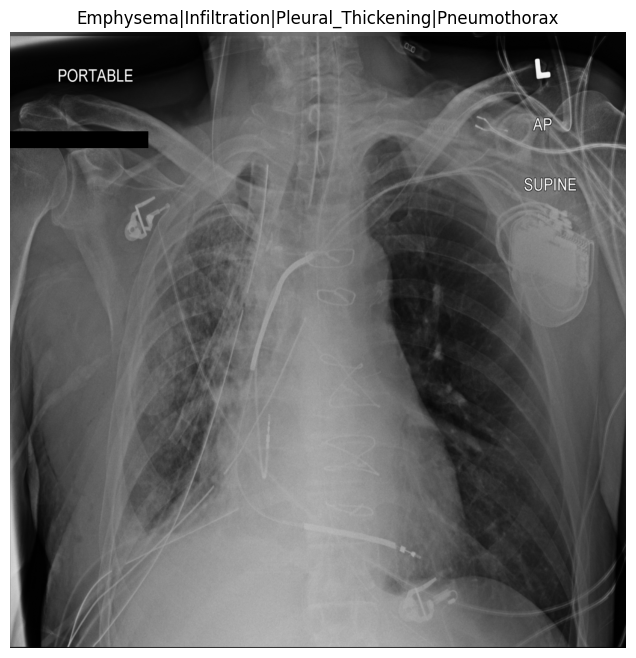

In [26]:
image = Image.open(image_path)

plt.figure(figsize=(8, 8))
plt.imshow(image, cmap="gray")
plt.axis("off")
plt.title(df.iloc[0]["Finding Labels"])
plt.show()

In [27]:
target_labels = [
    "Atelectasis",
    "Effusion",
    "Pneumonia"
]

print("Target diseases:")
for label in target_labels:
    print("-", label)

Target diseases:
- Atelectasis
- Effusion
- Pneumonia


In [28]:
for label in target_labels:
    df[label] = df["Finding Labels"].apply(
        lambda x: 1 if label in x.split("|") else 0
    )

In [29]:
print(df[[
    "Image Index",
    "Finding Labels",
    "Atelectasis",
    "Effusion",
    "Pneumonia"
]].head(20))

         Image Index                                     Finding Labels  \
0   00000013_005.png  Emphysema|Infiltration|Pleural_Thickening|Pneu...   
1   00000013_026.png                             Cardiomegaly|Emphysema   
2   00000017_001.png                                         No Finding   
3   00000030_001.png                                        Atelectasis   
4   00000032_001.png                        Cardiomegaly|Edema|Effusion   
5   00000040_003.png                                 Consolidation|Mass   
6   00000042_002.png                                         No Finding   
7   00000057_001.png                                         No Finding   
8   00000061_002.png                                           Effusion   
9   00000061_019.png                                         No Finding   
10  00000061_025.png         Consolidation|Effusion|Infiltration|Nodule   
11  00000079_000.png                                               Mass   
12  00000080_005.png     

In [30]:
print("Atelectasis:", df["Atelectasis"].sum())
print("Effusion:", df["Effusion"].sum())
print("Pneumonia:", df["Pneumonia"].sum())

Atelectasis: 508
Effusion: 644
Pneumonia: 62


In [31]:
df_model = df[
    (df["Atelectasis"] == 1) |
    (df["Effusion"] == 1) |
    (df["Pneumonia"] == 1)
].copy()

print("Original images:", len(df))
print("Images containing at least one target disease:", len(df_model))

Original images: 5606
Images containing at least one target disease: 1047


In [32]:
print("Unique patients:", df_model["Patient ID"].nunique())
print("Total images:", len(df_model))

Unique patients: 874
Total images: 1047


In [33]:
df_model.to_csv(
    "/content/chest_xray/prepared_labels.csv",
    index=False
)

print("Prepared dataset saved!")

Prepared dataset saved!


In [34]:
from sklearn.model_selection import train_test_split

In [35]:
patient_ids = df_model["Patient ID"].unique()

print("Total unique patients:", len(patient_ids))

Total unique patients: 874


In [36]:
train_patients, temp_patients = train_test_split(
    patient_ids,
    test_size=0.30,
    random_state=42
)

print("Training patients:", len(train_patients))
print("Temporary patients:", len(temp_patients))

Training patients: 611
Temporary patients: 263


In [37]:
val_patients, test_patients = train_test_split(
    temp_patients,
    test_size=0.50,
    random_state=42
)

print("Validation patients:", len(val_patients))
print("Test patients:", len(test_patients))

Validation patients: 131
Test patients: 132


In [38]:
train_df = df_model[
    df_model["Patient ID"].isin(train_patients)
].copy()

val_df = df_model[
    df_model["Patient ID"].isin(val_patients)
].copy()

test_df = df_model[
    df_model["Patient ID"].isin(test_patients)
].copy()

In [39]:
print("Training images:", len(train_df))
print("Validation images:", len(val_df))
print("Test images:", len(test_df))

print("\nTotal:", len(train_df) + len(val_df) + len(test_df))

Training images: 730
Validation images: 168
Test images: 149

Total: 1047


In [40]:
train_set = set(train_df["Patient ID"])
val_set = set(val_df["Patient ID"])
test_set = set(test_df["Patient ID"])

print("Train ∩ Validation:", len(train_set & val_set))
print("Train ∩ Test:", len(train_set & test_set))
print("Validation ∩ Test:", len(val_set & test_set))

Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0


In [41]:
print("TRAIN")
print(train_df[target_labels].sum())

print("\nVALIDATION")
print(val_df[target_labels].sum())

print("\nTEST")
print(test_df[target_labels].sum())

TRAIN
Atelectasis    350
Effusion       456
Pneumonia       46
dtype: int64

VALIDATION
Atelectasis    83
Effusion       99
Pneumonia       9
dtype: int64

TEST
Atelectasis    75
Effusion       89
Pneumonia       7
dtype: int64


In [42]:
import os

image_extensions = (".png", ".jpg", ".jpeg")

image_count = 0
example_images = []

for root, dirs, files in os.walk("/content/chest_xray"):
    for file in files:
        if file.lower().endswith(image_extensions):
            image_count += 1
            if len(example_images) < 10:
                example_images.append(os.path.join(root, file))

print("Total image files found:", image_count)

print("\nExample image paths:")
for path in example_images:
    print(path)

Total image files found: 11212

Example image paths:
/content/chest_xray/sample/sample/images/00013670_057.png
/content/chest_xray/sample/sample/images/00001629_000.png
/content/chest_xray/sample/sample/images/00008763_001.png
/content/chest_xray/sample/sample/images/00013572_006.png
/content/chest_xray/sample/sample/images/00006210_005.png
/content/chest_xray/sample/sample/images/00001086_001.png
/content/chest_xray/sample/sample/images/00025464_000.png
/content/chest_xray/sample/sample/images/00006058_002.png
/content/chest_xray/sample/sample/images/00004978_005.png
/content/chest_xray/sample/sample/images/00000809_001.png


In [43]:
image_paths = {}

for root, dirs, files in os.walk("/content/chest_xray"):
    for file in files:
        if file.lower().endswith(image_extensions):
            image_paths[file] = os.path.join(root, file)

print("Images indexed:", len(image_paths))

Images indexed: 5606


In [44]:
example_name = train_df.iloc[0]["Image Index"]

print("Image name:", example_name)
print("Image path:", image_paths.get(example_name))

Image name: 00000030_001.png
Image path: /content/chest_xray/sample/images/00000030_001.png


In [45]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import numpy as np

In [46]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=5),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [47]:
class ChestXrayDataset(Dataset):

    def __init__(self, dataframe, image_paths, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.image_paths = image_paths
        self.transform = transform

        self.labels = [
            "Atelectasis",
            "Effusion",
            "Pneumonia"
        ]

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):

        row = self.dataframe.iloc[idx]

        image_name = row["Image Index"]
        image_path = self.image_paths[image_name]

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = torch.tensor(
            row[self.labels].values.astype(np.float32)
        )

        return image, label

In [48]:
train_dataset = ChestXrayDataset(
    train_df,
    image_paths,
    train_transform
)

val_dataset = ChestXrayDataset(
    val_df,
    image_paths,
    val_test_transform
)

test_dataset = ChestXrayDataset(
    test_df,
    image_paths,
    val_test_transform
)

print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:", len(test_dataset))

Training samples: 730
Validation samples: 168
Test samples: 149


In [49]:
image, label = train_dataset[0]

print("Image tensor shape:", image.shape)
print("Label:", label)
print("Label shape:", label.shape)

Image tensor shape: torch.Size([3, 224, 224])
Label: tensor([1., 0., 0.])
Label shape: torch.Size([3])


In [50]:
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [51]:
images, labels = next(iter(train_loader))

print("Batch image shape:", images.shape)
print("Batch label shape:", labels.shape)

Batch image shape: torch.Size([16, 3, 224, 224])
Batch label shape: torch.Size([16, 3])


In [52]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

Using device: cuda


In [53]:
import torch
import torch.nn as nn
from torchvision import models

In [54]:
weights = models.DenseNet121_Weights.DEFAULT

model = models.densenet121(weights=weights)

print(model)

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 87.1MB/s]


DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu

In [55]:
print(model.classifier)

Linear(in_features=1024, out_features=1000, bias=True)


In [56]:
model.classifier = nn.Linear(
    model.classifier.in_features,
    3
)

print(model.classifier)

Linear(in_features=1024, out_features=3, bias=True)


In [57]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = model.to(device)

print("Model is using:", device)

Model is using: cuda


In [58]:
images, labels = next(iter(train_loader))

images = images.to(device)

with torch.no_grad():
    outputs = model(images)

print("Input shape:", images.shape)
print("Output shape:", outputs.shape)

Input shape: torch.Size([16, 3, 224, 224])
Output shape: torch.Size([16, 3])


In [59]:
print(outputs[0])

tensor([0.1631, 0.1380, 0.0833], device='cuda:0')


In [60]:
probabilities = torch.sigmoid(outputs)

print(probabilities[0])

tensor([0.5407, 0.5344, 0.5208], device='cuda:0')


In [61]:
criterion = nn.BCEWithLogitsLoss()

In [62]:
criterion = nn.BCEWithLogitsLoss()

print(criterion)

BCEWithLogitsLoss()


In [63]:
positive_counts = train_df[target_labels].sum()
negative_counts = len(train_df) - positive_counts

pos_weight = negative_counts / positive_counts

print("Positive counts:")
print(positive_counts)

print("\nNegative counts:")
print(negative_counts)

print("\nPositive weights:")
print(pos_weight)

Positive counts:
Atelectasis    350
Effusion       456
Pneumonia       46
dtype: int64

Negative counts:
Atelectasis    380
Effusion       274
Pneumonia      684
dtype: int64

Positive weights:
Atelectasis     1.085714
Effusion        0.600877
Pneumonia      14.869565
dtype: float64


In [64]:
positive_counts = train_df[target_labels].sum()
negative_counts = len(train_df) - positive_counts

pos_weight = torch.tensor(
    (negative_counts / positive_counts).values,
    dtype=torch.float32
).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

print("Positive counts:")
print(positive_counts)

print("\nNegative counts:")
print(negative_counts)

print("\nPositive weights:")
print(pos_weight)

Positive counts:
Atelectasis    350
Effusion       456
Pneumonia       46
dtype: int64

Negative counts:
Atelectasis    380
Effusion       274
Pneumonia      684
dtype: int64

Positive weights:
tensor([ 1.0857,  0.6009, 14.8696], device='cuda:0')


In [65]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

print(optimizer)

AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0.0001
)


In [66]:
num_epochs = 5

In [67]:
from sklearn.metrics import roc_auc_score
import numpy as np

num_epochs = 5

best_val_loss = float("inf")
best_model_path = "/content/best_densenet121.pth"

train_losses = []
val_losses = []

for epoch in range(num_epochs):

    # -------------------------
    # TRAINING
    # -------------------------
    model.train()

    running_train_loss = 0.0

    for images, labels in train_loader:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_train_loss += loss.item() * images.size(0)

    train_loss = running_train_loss / len(train_loader.dataset)

    # -------------------------
    # VALIDATION
    # -------------------------
    model.eval()

    running_val_loss = 0.0

    all_val_labels = []
    all_val_probs = []

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_val_loss += loss.item() * images.size(0)

            probabilities = torch.sigmoid(outputs)

            all_val_labels.append(labels.cpu().numpy())
            all_val_probs.append(probabilities.cpu().numpy())

    val_loss = running_val_loss / len(val_loader.dataset)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    # Combine validation predictions
    all_val_labels = np.concatenate(all_val_labels)
    all_val_probs = np.concatenate(all_val_probs)

    # Calculate AUC for each disease
    auc_scores = []

    for i, disease in enumerate(target_labels):

        try:
            auc = roc_auc_score(
                all_val_labels[:, i],
                all_val_probs[:, i]
            )
            auc_scores.append(auc)
        except ValueError:
            auc_scores.append(np.nan)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Val Loss: {val_loss:.4f}"
    )

    for disease, auc in zip(target_labels, auc_scores):
        print(f"  {disease} AUC: {auc:.4f}")

    # Save best model
    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            model.state_dict(),
            best_model_path
        )

        print("  ✓ Best model saved")

Epoch [1/5] Train Loss: 0.8440 Val Loss: 0.8058
  Atelectasis AUC: 0.6814
  Effusion AUC: 0.6760
  Pneumonia AUC: 0.6045
  ✓ Best model saved
Epoch [2/5] Train Loss: 0.7293 Val Loss: 0.7886
  Atelectasis AUC: 0.6624
  Effusion AUC: 0.6421
  Pneumonia AUC: 0.6443
  ✓ Best model saved
Epoch [3/5] Train Loss: 0.6368 Val Loss: 0.7920
  Atelectasis AUC: 0.6808
  Effusion AUC: 0.6593
  Pneumonia AUC: 0.6716
Epoch [4/5] Train Loss: 0.5418 Val Loss: 0.7559
  Atelectasis AUC: 0.7070
  Effusion AUC: 0.7093
  Pneumonia AUC: 0.7526
  ✓ Best model saved
Epoch [5/5] Train Loss: 0.5267 Val Loss: 0.7807
  Atelectasis AUC: 0.6770
  Effusion AUC: 0.6851
  Pneumonia AUC: 0.7079


In [68]:
import os

print("Model exists:", os.path.exists(best_model_path))

if os.path.exists(best_model_path):
    size_mb = os.path.getsize(best_model_path) / (1024 * 1024)
    print(f"Model size: {size_mb:.2f} MB")

Model exists: True
Model size: 27.12 MB


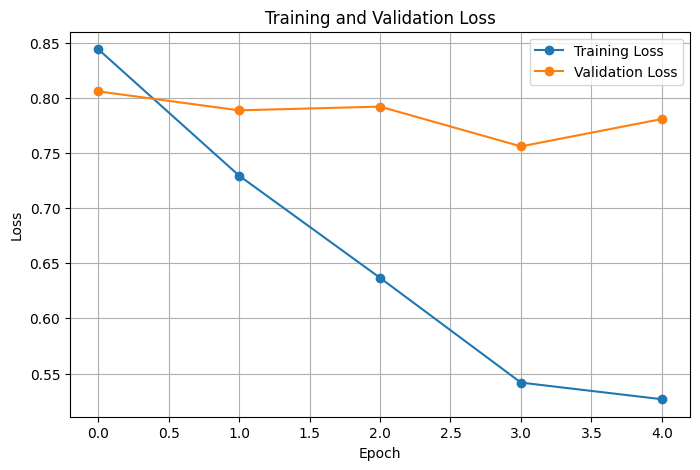

In [69]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(train_losses, marker="o", label="Training Loss")
plt.plot(val_losses, marker="o", label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

In [70]:
model.load_state_dict(
    torch.load(
        "/content/best_densenet121.pth",
        map_location=device
    )
)

model = model.to(device)

print("Best model loaded successfully!")

Best model loaded successfully!


In [71]:
model.eval()

all_test_labels = []
all_test_probs = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        probabilities = torch.sigmoid(outputs)

        all_test_labels.append(labels.cpu().numpy())
        all_test_probs.append(probabilities.cpu().numpy())

all_test_labels = np.concatenate(all_test_labels)
all_test_probs = np.concatenate(all_test_probs)

print("Test labels shape:", all_test_labels.shape)
print("Test probabilities shape:", all_test_probs.shape)

Test labels shape: (149, 3)
Test probabilities shape: (149, 3)


In [72]:
from sklearn.metrics import roc_auc_score

print("TEST ROC-AUC")
print("-" * 30)

for i, disease in enumerate(target_labels):

    auc = roc_auc_score(
        all_test_labels[:, i],
        all_test_probs[:, i]
    )

    print(f"{disease}: {auc:.4f}")

TEST ROC-AUC
------------------------------
Atelectasis: 0.7014
Effusion: 0.6869
Pneumonia: 0.5765


In [73]:
threshold = 0.5

all_test_preds = (
    all_test_probs >= threshold
).astype(int)

print("First 10 predictions:")
print(all_test_preds[:10])

print("\nFirst 10 actual labels:")
print(all_test_labels[:10].astype(int))

First 10 predictions:
[[0 1 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [0 1 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]]

First 10 actual labels:
[[0 1 0]
 [0 1 0]
 [0 1 0]
 [0 0 1]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [0 1 0]
 [1 1 0]]


In [74]:
from sklearn.metrics import classification_report

print(
    classification_report(
        all_test_labels,
        all_test_preds,
        target_names=target_labels,
        zero_division=0
    )
)

              precision    recall  f1-score   support

 Atelectasis       0.66      0.68      0.67        75
    Effusion       0.74      0.63      0.68        89
   Pneumonia       0.11      0.29      0.16         7

   micro avg       0.64      0.64      0.64       171
   macro avg       0.50      0.53      0.50       171
weighted avg       0.68      0.64      0.65       171
 samples avg       0.62      0.65      0.62       171



In [75]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

for i, disease in enumerate(target_labels):

    cm = confusion_matrix(
        all_test_labels[:, i],
        all_test_preds[:, i]
    )

    print(f"\n{disease}")
    print(cm)


Atelectasis
[[48 26]
 [24 51]]

Effusion
[[40 20]
 [33 56]]

Pneumonia
[[126  16]
 [  5   2]]


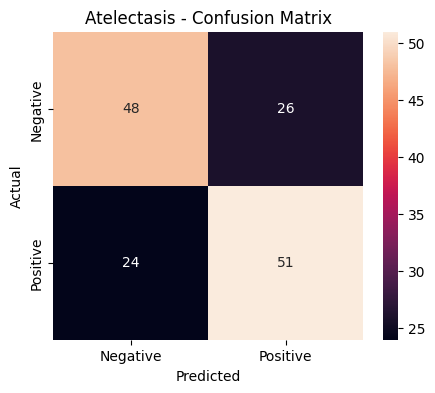

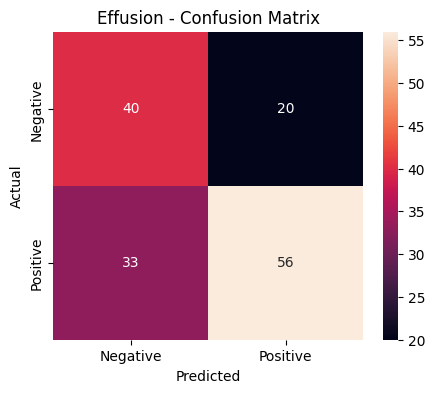

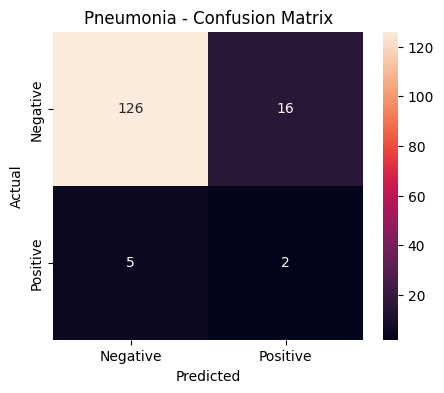

In [76]:
import seaborn as sns

for i, disease in enumerate(target_labels):

    cm = confusion_matrix(
        all_test_labels[:, i],
        all_test_preds[:, i]
    )

    plt.figure(figsize=(5, 4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=["Negative", "Positive"],
        yticklabels=["Negative", "Positive"]
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"{disease} - Confusion Matrix")

    plt.show()

In [77]:
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("=" * 60)
print("FINAL TEST RESULTS")
print("=" * 60)

for i, disease in enumerate(target_labels):

    y_true = all_test_labels[:, i]
    y_pred = all_test_preds[:, i]
    y_prob = all_test_probs[:, i]

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc = roc_auc_score(y_true, y_prob)

    print(f"\n{disease}")
    print("-" * 30)
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC-AUC  : {auc:.4f}")

FINAL TEST RESULTS

Atelectasis
------------------------------
Accuracy : 0.6644
Precision: 0.6623
Recall   : 0.6800
F1 Score : 0.6711
ROC-AUC  : 0.7014

Effusion
------------------------------
Accuracy : 0.6443
Precision: 0.7368
Recall   : 0.6292
F1 Score : 0.6788
ROC-AUC  : 0.6869

Pneumonia
------------------------------
Accuracy : 0.8591
Precision: 0.1111
Recall   : 0.2857
F1 Score : 0.1600
ROC-AUC  : 0.5765


In [78]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

macro_precision = precision_score(
    all_test_labels,
    all_test_preds,
    average="macro",
    zero_division=0
)

macro_recall = recall_score(
    all_test_labels,
    all_test_preds,
    average="macro",
    zero_division=0
)

macro_f1 = f1_score(
    all_test_labels,
    all_test_preds,
    average="macro",
    zero_division=0
)

micro_precision = precision_score(
    all_test_labels,
    all_test_preds,
    average="micro",
    zero_division=0
)

micro_recall = recall_score(
    all_test_labels,
    all_test_preds,
    average="micro",
    zero_division=0
)

micro_f1 = f1_score(
    all_test_labels,
    all_test_preds,
    average="micro",
    zero_division=0
)

print("MACRO METRICS")
print("Precision:", round(macro_precision, 4))
print("Recall:", round(macro_recall, 4))
print("F1:", round(macro_f1, 4))

print("\nMICRO METRICS")
print("Precision:", round(micro_precision, 4))
print("Recall:", round(micro_recall, 4))
print("F1:", round(micro_f1, 4))

MACRO METRICS
Precision: 0.5034
Recall: 0.5316
F1: 0.5033

MICRO METRICS
Precision: 0.6374
Recall: 0.6374
F1: 0.6374


In [79]:
import pandas as pd

baseline_results = pd.DataFrame({
    "Disease": target_labels,
    "Accuracy": [
        accuracy_score(all_test_labels[:, i], all_test_preds[:, i])
        for i in range(3)
    ],
    "Precision": [
        precision_score(all_test_labels[:, i], all_test_preds[:, i], zero_division=0)
        for i in range(3)
    ],
    "Recall": [
        recall_score(all_test_labels[:, i], all_test_preds[:, i], zero_division=0)
        for i in range(3)
    ],
    "F1": [
        f1_score(all_test_labels[:, i], all_test_preds[:, i], zero_division=0)
        for i in range(3)
    ],
    "ROC_AUC": [
        roc_auc_score(all_test_labels[:, i], all_test_probs[:, i])
        for i in range(3)
    ]
})

baseline_results

,Disease,Accuracy,Precision,Recall,F1,ROC_AUC
0,Atelectasis,0.664430,0.662338,0.680000,0.671053,0.701441
1,Effusion,0.644295,0.736842,0.629213,0.678788,0.686891
2,Pneumonia,0.859060,0.111111,0.285714,0.160000,0.576459


In [80]:
baseline_results.to_csv(
    "/content/baseline_results.csv",
    index=False
)

print("Baseline results saved.")

Baseline results saved.


In [81]:
!pip install -q grad-cam

In [82]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

print("Grad-CAM imported successfully!")

Grad-CAM imported successfully!


In [83]:
target_layers = [model.features.denseblock4]

print(target_layers)

[_DenseBlock(
  (denselayer1): _DenseLayer(
    (norm1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu1): ReLU(inplace=True)
    (conv1): Conv2d(512, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu2): ReLU(inplace=True)
    (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  )
  (denselayer2): _DenseLayer(
    (norm1): BatchNorm2d(544, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu1): ReLU(inplace=True)
    (conv1): Conv2d(544, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu2): ReLU(inplace=True)
    (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  )
  (denselayer3): _DenseLayer(
    (norm1): BatchNorm2d(576, eps=1e-05, momen

In [84]:
sample_row = test_df.iloc[0]

sample_image_name = sample_row["Image Index"]
sample_image_path = image_paths[sample_image_name]

print("Image:", sample_image_name)
print("Path:", sample_image_path)
print("Actual labels:")
print(sample_row[target_labels])

Image: 00000099_003.png
Path: /content/chest_xray/sample/images/00000099_003.png
Actual labels:
Atelectasis    0
Effusion       1
Pneumonia      0
Name: 16, dtype: object


In [85]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

original_image = Image.open(
    sample_image_path
).convert("RGB")

print("Original size:", original_image.size)

Original size: (1024, 1024)


In [86]:
input_tensor = val_test_transform(
    original_image
).unsqueeze(0).to(device)

print("Input tensor shape:", input_tensor.shape)

Input tensor shape: torch.Size([1, 3, 224, 224])


In [87]:
model.eval()

with torch.no_grad():
    output = model(input_tensor)

probabilities = torch.sigmoid(output)[0]

for disease, probability in zip(
    target_labels,
    probabilities
):
    print(
        f"{disease}: {probability.item() * 100:.2f}%"
    )

Atelectasis: 37.40%
Effusion: 79.03%
Pneumonia: 7.89%


In [88]:
predicted_class = torch.argmax(probabilities).item()

print("Highest predicted class:", target_labels[predicted_class])
print(
    "Confidence:",
    f"{probabilities[predicted_class].item() * 100:.2f}%"
)

Highest predicted class: Effusion
Confidence: 79.03%


In [89]:
cam = GradCAM(
    model=model,
    target_layers=target_layers
)

targets = [
    ClassifierOutputTarget(predicted_class)
]

grayscale_cam = cam(
    input_tensor=input_tensor,
    targets=targets
)

grayscale_cam = grayscale_cam[0]

print("Grad-CAM generated successfully!")
print("CAM shape:", grayscale_cam.shape)

Grad-CAM generated successfully!
CAM shape: (224, 224)


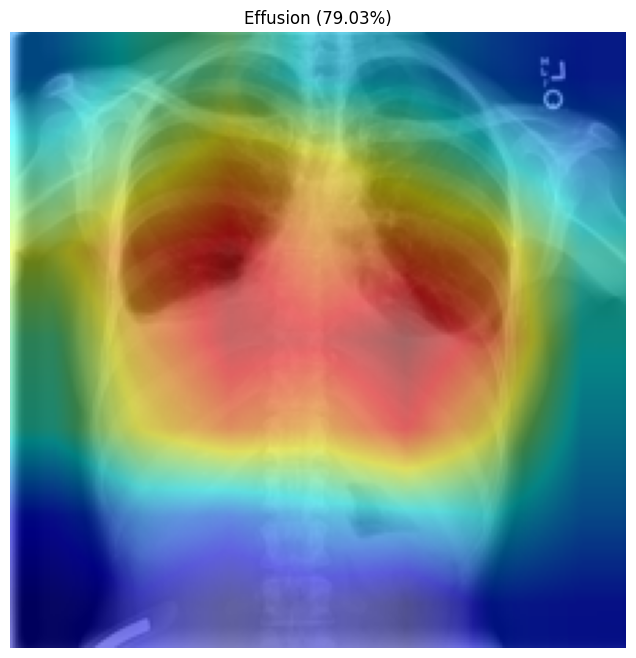

In [90]:
display_image = np.array(
    original_image.resize((224, 224))
).astype(np.float32) / 255.0

visualization = show_cam_on_image(
    display_image,
    grayscale_cam,
    use_rgb=True
)

plt.figure(figsize=(8, 8))
plt.imshow(visualization)
plt.axis("off")

plt.title(
    f"{target_labels[predicted_class]} "
    f"({probabilities[predicted_class].item() * 100:.2f}%)"
)

plt.show()

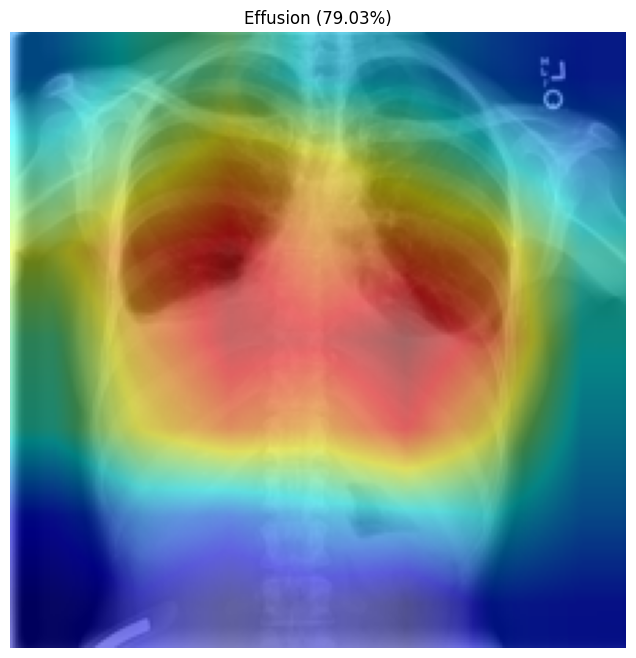

Saved: /content/gradcam_example.png


In [91]:
gradcam_path = "/content/gradcam_example.png"

plt.figure(figsize=(8, 8))
plt.imshow(visualization)
plt.axis("off")
plt.title(
    f"{target_labels[predicted_class]} "
    f"({probabilities[predicted_class].item() * 100:.2f}%)"
)

plt.savefig(
    gradcam_path,
    bbox_inches="tight",
    dpi=200
)

plt.show()

print("Saved:", gradcam_path)

In [92]:
def predict_xray(image_path):

    # Load image
    image = Image.open(image_path).convert("RGB")

    # Preprocess image
    input_tensor = val_test_transform(image).unsqueeze(0).to(device)

    # Model prediction
    model.eval()

    with torch.no_grad():
        output = model(input_tensor)

    # Convert logits to probabilities
    probabilities = torch.sigmoid(output)[0]

    # Print results
    print("=" * 45)
    print("CHEST X-RAY AI PREDICTION")
    print("=" * 45)

    for disease, probability in zip(target_labels, probabilities):

        print(
            f"{disease:<15}: "
            f"{probability.item() * 100:.2f}%"
        )

    print("=" * 45)
    print("Educational use only - NOT a clinical diagnosis.")

    return probabilities

In [93]:
probabilities = predict_xray(sample_image_path)

CHEST X-RAY AI PREDICTION
Atelectasis    : 37.40%
Effusion       : 79.03%
Pneumonia      : 7.89%
Educational use only - NOT a clinical diagnosis.


In [94]:
def predict_xray(image_path):

    # Load image
    image = Image.open(image_path).convert("RGB")

    # Preprocess
    input_tensor = val_test_transform(image).unsqueeze(0).to(device)

    # Prediction
    model.eval()

    with torch.no_grad():
        output = model(input_tensor)

    # Convert logits to probabilities
    probabilities = torch.sigmoid(output)[0]

    # Find highest probability
    predicted_class = torch.argmax(probabilities).item()

    predicted_disease = target_labels[predicted_class]

    confidence = probabilities[predicted_class].item()

    # Display results
    print("=" * 50)
    print("CHEST X-RAY AI PREDICTION")
    print("=" * 50)

    for disease, probability in zip(
        target_labels,
        probabilities
    ):

        print(
            f"{disease:<15}: "
            f"{probability.item() * 100:.2f}%"
        )

    print("-" * 50)

    print(
        f"Highest predicted abnormality: "
        f"{predicted_disease}"
    )

    print(
        f"Associated model probability: "
        f"{confidence * 100:.2f}%"
    )

    print("-" * 50)
    print(
        "Educational use only - "
        "NOT a clinical diagnosis."
    )

    return predicted_disease, confidence, probabilities

In [95]:
predicted_disease, confidence, probabilities = predict_xray(
    sample_image_path
)

CHEST X-RAY AI PREDICTION
Atelectasis    : 37.40%
Effusion       : 79.03%
Pneumonia      : 7.89%
--------------------------------------------------
Highest predicted abnormality: Effusion
Associated model probability: 79.03%
--------------------------------------------------
Educational use only - NOT a clinical diagnosis.


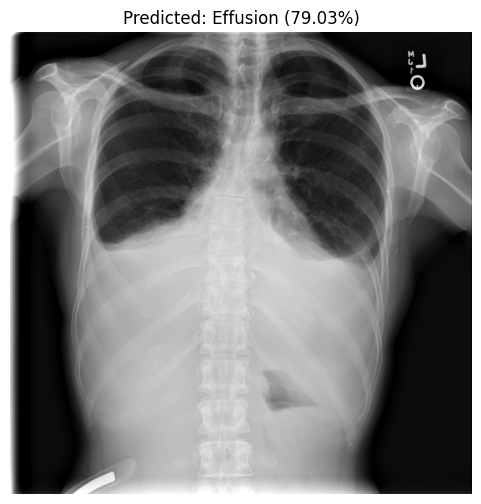

In [96]:
plt.figure(figsize=(6, 6))

plt.imshow(Image.open(sample_image_path).convert("RGB"))

plt.axis("off")

plt.title(
    f"Predicted: {predicted_disease} "
    f"({confidence * 100:.2f}%)"
)

plt.show()

In [97]:
!pip install -q gradio

In [98]:
import gradio as gr

print("Gradio imported successfully!")

Gradio imported successfully!


In [99]:
def gradio_predict(image):

    # Check whether an image was uploaded
    if image is None:
        return {
            "Atelectasis": 0,
            "Effusion": 0,
            "Pneumonia": 0
        }

    # Convert image to PIL
    image = Image.fromarray(image).convert("RGB")

    # Preprocess
    input_tensor = val_test_transform(image).unsqueeze(0).to(device)

    # Model prediction
    model.eval()

    with torch.no_grad():
        output = model(input_tensor)

    # Convert logits to probabilities
    probabilities = torch.sigmoid(output)[0].cpu().numpy()

    # Create result dictionary
    results = {
        disease: float(probability)
        for disease, probability in zip(
            target_labels,
            probabilities
        )
    }

    return results

In [100]:
test_image = np.array(
    Image.open(sample_image_path).convert("RGB")
)

result = gradio_predict(test_image)

print(result)

{'Atelectasis': 0.374023973941803, 'Effusion': 0.7902601361274719, 'Pneumonia': 0.07892970740795135}


In [101]:
def generate_gradcam(image):

    # Convert image to PIL
    image_pil = Image.fromarray(image).convert("RGB")

    # Preprocess
    input_tensor = val_test_transform(
        image_pil
    ).unsqueeze(0).to(device)

    # Model prediction
    model.eval()

    with torch.no_grad():
        output = model(input_tensor)

    probabilities = torch.sigmoid(output)[0]

    # Select highest probability disease
    predicted_class = torch.argmax(probabilities).item()

    predicted_disease = target_labels[predicted_class]

    confidence = probabilities[
        predicted_class
    ].item()

    # Create Grad-CAM
    cam = GradCAM(
        model=model,
        target_layers=target_layers
    )

    targets = [
        ClassifierOutputTarget(predicted_class)
    ]

    grayscale_cam = cam(
        input_tensor=input_tensor,
        targets=targets
    )[0]

    # Resize image
    display_image = np.array(
        image_pil.resize((224, 224))
    ).astype(np.float32) / 255.0

    # Generate overlay
    visualization = show_cam_on_image(
        display_image,
        grayscale_cam,
        use_rgb=True
    )

    return visualization

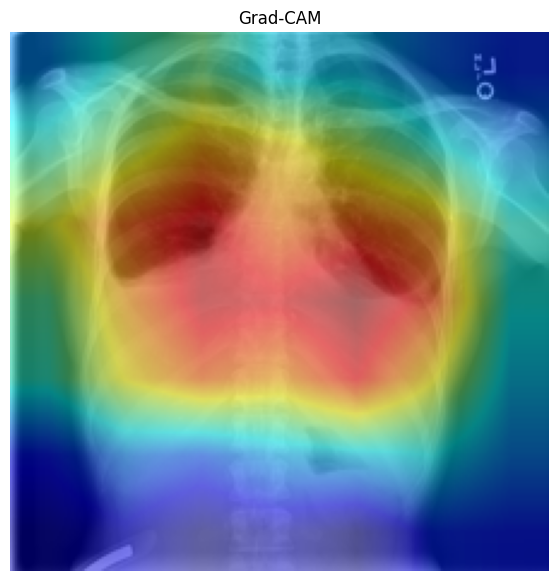

In [102]:
gradcam_result = generate_gradcam(test_image)

plt.figure(figsize=(7, 7))

plt.imshow(gradcam_result)

plt.axis("off")

plt.title("Grad-CAM")

plt.show()

In [103]:
def analyze_xray(image):

    if image is None:
        return (
            {},
            None,
            "Please upload a chest X-ray."
        )

    # Convert to PIL
    image_pil = Image.fromarray(image).convert("RGB")

    # Preprocess
    input_tensor = val_test_transform(
        image_pil
    ).unsqueeze(0).to(device)

    # Model prediction
    model.eval()

    with torch.no_grad():
        output = model(input_tensor)

    probabilities = torch.sigmoid(output)[0]

    # Convert probabilities to dictionary
    results = {
        disease: float(probability)
        for disease, probability in zip(
            target_labels,
            probabilities
        )
    }

    # Highest probability
    predicted_class = torch.argmax(
        probabilities
    ).item()

    predicted_disease = target_labels[
        predicted_class
    ]

    confidence = probabilities[
        predicted_class
    ].item()

    # Grad-CAM
    cam = GradCAM(
        model=model,
        target_layers=target_layers
    )

    targets = [
        ClassifierOutputTarget(
            predicted_class
        )
    ]

    grayscale_cam = cam(
        input_tensor=input_tensor,
        targets=targets
    )[0]

    display_image = np.array(
        image_pil.resize((224, 224))
    ).astype(np.float32) / 255.0

    visualization = show_cam_on_image(
        display_image,
        grayscale_cam,
        use_rgb=True
    )

    message = (
        f"Highest model prediction: "
        f"{predicted_disease}\n"
        f"Model probability: "
        f"{confidence * 100:.2f}%\n\n"
        f"Educational use only — "
        f"NOT a clinical diagnosis."
    )

    return results, visualization, message

{'Atelectasis': 0.374023973941803, 'Effusion': 0.7902601361274719, 'Pneumonia': 0.07892970740795135}
Highest model prediction: Effusion
Model probability: 79.03%

Educational use only — NOT a clinical diagnosis.


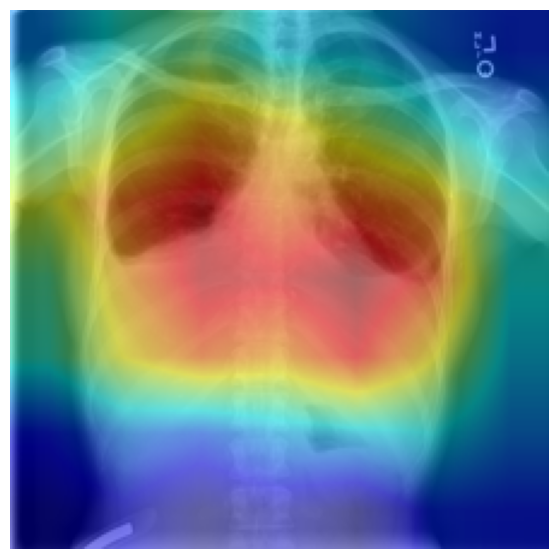

In [106]:
results, cam_image, message = analyze_xray(
    test_image
)

print(results)
print(message)

plt.figure(figsize=(7, 7))
plt.imshow(cam_image)
plt.axis("off")
plt.show()

In [107]:
demo = gr.Interface(
    fn=analyze_xray,

    inputs=gr.Image(
        type="numpy",
        label="Upload Chest X-Ray"
    ),

    outputs=[
        gr.Label(
            num_top_classes=3,
            label="Disease Predictions"
        ),

        gr.Image(
            label="Grad-CAM Visualization"
        ),

        gr.Textbox(
            label="Prediction Information"
        )
    ],

    title="Chest X-Ray Disease Classification",

    description=(
        "Educational AI system using "
        "pretrained DenseNet121 to estimate "
        "selected chest X-ray abnormalities."
    ),

    flagging_mode="never"
)

In [108]:
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e2ab71edfe2c191f0d.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [110]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [111]:
import os

project_dir = "/content/drive/MyDrive/Chest_Xray_AI_Project"

os.makedirs(project_dir, exist_ok=True)

print("Project folder created:")
print(project_dir)

Project folder created:
/content/drive/MyDrive/Chest_Xray_AI_Project


In [112]:
import shutil

shutil.copy(
    "/content/best_densenet121.pth",
    f"{project_dir}/best_densenet121.pth"
)

print("Best model copied to Google Drive.")

Best model copied to Google Drive.


In [113]:
baseline_results.to_csv(
    f"{project_dir}/baseline_results.csv",
    index=False
)

print("Baseline results saved.")

Baseline results saved.


In [114]:
from PIL import Image

Image.fromarray(
    gradcam_result
).save(
    f"{project_dir}/gradcam_example.png"
)

print("Grad-CAM example saved.")

Grad-CAM example saved.


In [115]:
demo.launch(share=True)

Rerunning server... use `close()` to stop if you need to change `launch()` parameters.
----
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e2ab71edfe2c191f0d.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [117]:
demo = gr.Interface(
    fn=analyze_xray,

    inputs=gr.Image(
        type="numpy",
        label="Upload Chest X-Ray"
    ),

    outputs=[
        gr.Label(
            num_top_classes=3,
            label="Model Predictions"
        ),

        gr.Image(
            label="Grad-CAM Visualization"
        ),

        gr.Textbox(
            label="Analysis"
        )
    ],

    title="🫁 Chest X-Ray Disease Classification",

    description=(
        "AI-based educational system using a pretrained "
        "DenseNet121 model to estimate selected chest "
        "X-ray abnormalities."
    ),

    article=(
        "⚠️ IMPORTANT: This system is developed for "
        "educational and research purposes only. "
        "Predictions are model outputs and must NOT "
        "be interpreted as clinical diagnoses."
    ),

    flagging_mode="never"
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://1700e1baaa3b0d57fc.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [118]:
import random

test_samples = test_df.sample(
    n=5,
    random_state=42
)

test_samples[
    ["Image Index"] + target_labels
]

,Image Index,Atelectasis,Effusion,Pneumonia
3027,00014879_006.png,0,1,0
1224,00006462_010.png,1,1,0
4355,00021495_007.png,1,1,0
3194,00015715_001.png,1,0,0
3057,00015069_000.png,0,0,1


In [119]:
import random

test_samples = test_df.sample(
    n=5,
    random_state=42
)

test_samples[
    ["Image Index"] + target_labels
]

,Image Index,Atelectasis,Effusion,Pneumonia
3027,00014879_006.png,0,1,0
1224,00006462_010.png,1,1,0
4355,00021495_007.png,1,1,0
3194,00015715_001.png,1,0,0
3057,00015069_000.png,0,0,1


In [120]:
for _, row in test_samples.iterrows():

    image_name = row["Image Index"]
    image_path = image_paths[image_name]

    print("\n" + "=" * 60)
    print("IMAGE:", image_name)

    print("ACTUAL LABELS:")

    for disease in target_labels:

        print(
            f"{disease}:",
            int(row[disease])
        )

    print("-" * 60)

    predicted_disease, confidence, probabilities = predict_xray(
        image_path
    )


IMAGE: 00014879_006.png
ACTUAL LABELS:
Atelectasis: 0
Effusion: 1
Pneumonia: 0
------------------------------------------------------------
CHEST X-RAY AI PREDICTION
Atelectasis    : 57.33%
Effusion       : 42.06%
Pneumonia      : 30.22%
--------------------------------------------------
Highest predicted abnormality: Atelectasis
Associated model probability: 57.33%
--------------------------------------------------
Educational use only - NOT a clinical diagnosis.

IMAGE: 00006462_010.png
ACTUAL LABELS:
Atelectasis: 1
Effusion: 1
Pneumonia: 0
------------------------------------------------------------
CHEST X-RAY AI PREDICTION
Atelectasis    : 64.45%
Effusion       : 56.68%
Pneumonia      : 22.05%
--------------------------------------------------
Highest predicted abnormality: Atelectasis
Associated model probability: 64.45%
--------------------------------------------------
Educational use only - NOT a clinical diagnosis.

IMAGE: 00021495_007.png
ACTUAL LABELS:
Atelectasis: 1
Effus

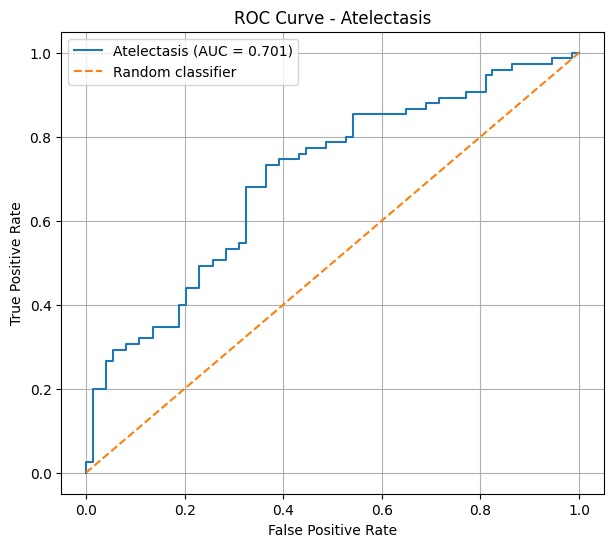

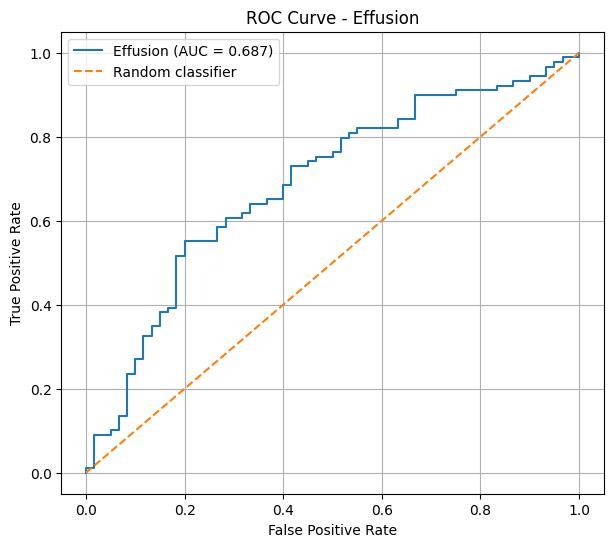

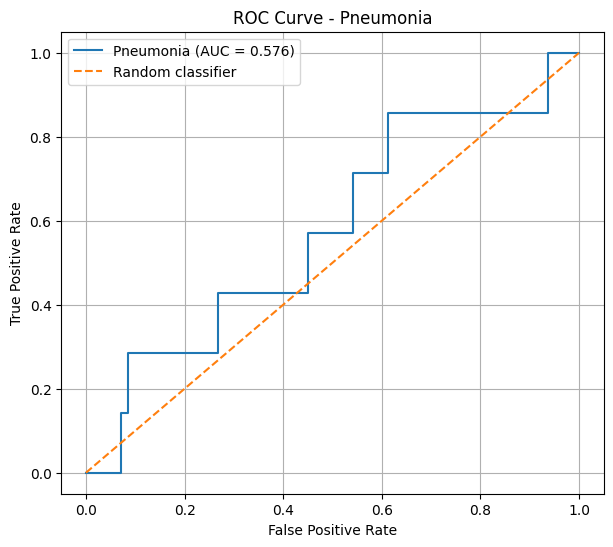

In [121]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

for i, disease in enumerate(target_labels):

    y_true = all_test_labels[:, i]
    y_prob = all_test_probs[:, i]

    fpr, tpr, _ = roc_curve(
        y_true,
        y_prob
    )

    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(7, 6))

    plt.plot(
        fpr,
        tpr,
        label=f"{disease} (AUC = {roc_auc:.3f})"
    )

    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        label="Random classifier"
    )

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")

    plt.title(
        f"ROC Curve - {disease}"
    )

    plt.legend()

    plt.grid(True)

    plt.show()

In [122]:
final_results = baseline_results.copy()

final_results[
    [
        "Disease",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC_AUC"
    ]
]

,Disease,Accuracy,Precision,Recall,F1,ROC_AUC
0,Atelectasis,0.664430,0.662338,0.680000,0.671053,0.701441
1,Effusion,0.644295,0.736842,0.629213,0.678788,0.686891
2,Pneumonia,0.859060,0.111111,0.285714,0.160000,0.576459


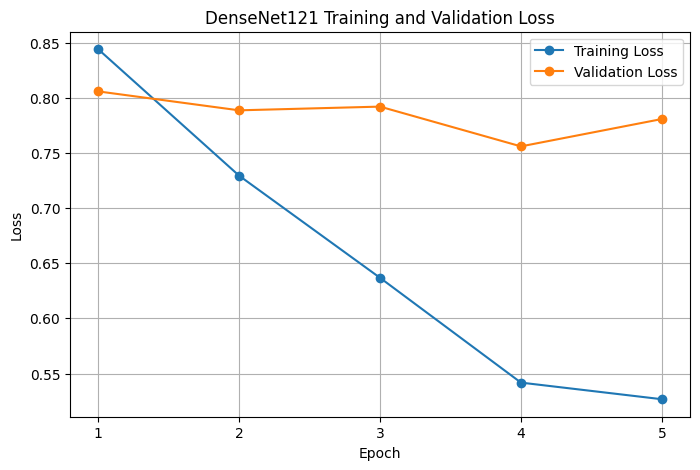

In [123]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(train_losses) + 1),
    train_losses,
    marker="o",
    label="Training Loss"
)

plt.plot(
    range(1, len(val_losses) + 1),
    val_losses,
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "DenseNet121 Training and Validation Loss"
)

plt.xticks(
    range(1, len(train_losses) + 1)
)

plt.legend()

plt.grid(True)

plt.show()

In [124]:
import os

project_dir = "/content/drive/MyDrive/Chest_Xray_AI_Project"

os.makedirs(
    project_dir,
    exist_ok=True
)

print(project_dir)

/content/drive/MyDrive/Chest_Xray_AI_Project


In [125]:
final_results.to_csv(
    f"{project_dir}/final_results.csv",
    index=False
)

print("Final results saved.")

Final results saved.


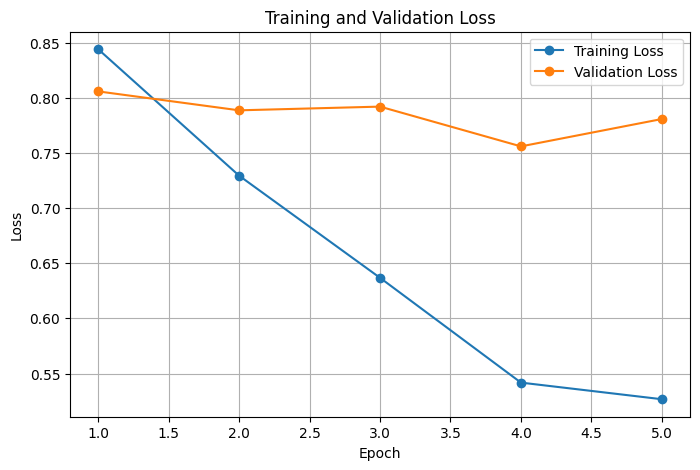

In [126]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(train_losses) + 1),
    train_losses,
    marker="o",
    label="Training Loss"
)

plt.plot(
    range(1, len(val_losses) + 1),
    val_losses,
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.savefig(
    f"{project_dir}/training_validation_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()